# Fire Spread on a Building Graph

> Pedagogical network model for stochastic spreading dynamics

This notebook formulates a simplified fire-spread process on a building represented as a graph.

- Each node represents a room.
- Each edge represents adjacency (doorway, corridor, or stair connection).
- Each edge carries a weight `w` interpreted as thermal resistance / insulation.

We simulate a discrete-time process with three states:

- **S**: susceptible (not burning)
- **I**: burning
- **R**: burned out

At each time step:
1. Burning rooms attempt to ignite susceptible neighbors.
2. Burning rooms remain active for `burn_time` steps, then transition to burned out.

This is a **didactic** model for network dynamics. It is not a fire-safety engineering model and should not be used for operational safety decisions.

## 1. Computational setup

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(42)


## 2. Construct a building graph

We model a single floor as a rectangular grid graph.

Then, for each edge `(u, v)`, we assign a resistance weight `w_uv` sampled from a bounded interval.

- Lower `w_uv`: easier transmission across the connection.
- Higher `w_uv`: stronger resistance (e.g., heavier fire doors, better compartmentalization).

In [ ]:
def make_building_grid(n_rows=4, n_cols=6, weight_low=0.2, weight_high=3.0, rng=None):
    """Construct a rectangular building graph with edge-resistance weights.

    Parameters
    ----------
    n_rows, n_cols : int
        Grid dimensions (rooms arranged as row/column nodes).
    weight_low, weight_high : float
        Bounds for uniform sampling of resistance weights `w`.
    rng : numpy.random.Generator or None
        Random number generator for reproducible sampling.

    Returns
    -------
    nx.Graph
        Undirected grid graph with edge attribute `w`.
    """
    if n_rows <= 0 or n_cols <= 0:
        raise ValueError("n_rows and n_cols must be positive integers")
    if rng is None:
        rng = np.random.default_rng()

    G = nx.grid_2d_graph(n_rows, n_cols)  # nodes are tuples (row, col)

    # Assign insulation/resistance weight to each connection.
    for u, v in G.edges():
        G[u][v]["w"] = float(rng.uniform(weight_low, weight_high))

    return G


G = make_building_grid(n_rows=4, n_cols=7, rng=rng)

print("Rooms (nodes):", G.number_of_nodes())
print("Connections (edges):", G.number_of_edges())

# Fixed layout for consistent figures: x=column, y=-row.
pos = {node: (node[1], -node[0]) for node in G.nodes()}

Rooms (nodes): 28
Connections (edges): 45


### Visualize the building and edge resistances

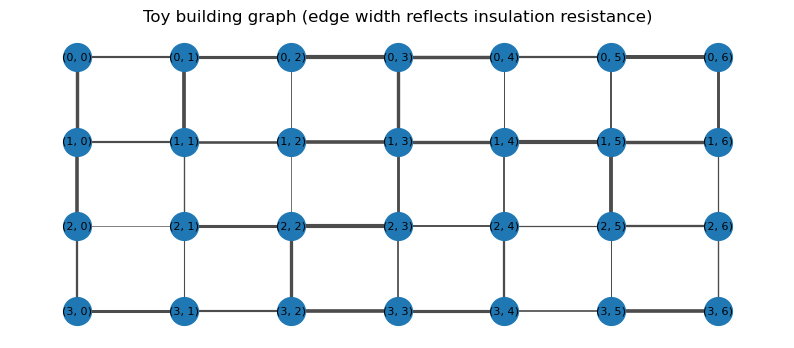

In [ ]:
def draw_building(G, pos, ax=None):
    """Draw the weighted building graph.

    Edge thickness is proportional to resistance weight `w` to make
    high-resistance links visually distinguishable.
    """
    if ax is None:
        ax = plt.gca()

    if G.number_of_edges() > 0:
        w = np.array([G[u][v]["w"] for u, v in G.edges()])
        widths = 0.5 + 2.5 * (w - w.min()) / (w.max() - w.min() + 1e-12)
    else:
        widths = 1.0

    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.7)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=400)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
    ax.set_title("Toy building graph (edge width reflects insulation resistance)")
    ax.axis("off")


plt.figure(figsize=(10, 4))
draw_building(G, pos)
plt.show()

## 3. Stochastic fire-spread model

We implement a discrete-time, synchronous update rule.

For a burning node `u` and susceptible neighbor `v`, ignition probability depends on edge resistance `w_uv`:

`p_ignite = 1 - exp(-beta / (1 + w_uv))`

Interpretation:
- Larger `beta` increases spread intensity.
- Larger `w_uv` decreases transmission probability.

Each burning room remains in state `I` for `burn_time` steps before transitioning to `R`.

In [ ]:
from dataclasses import dataclass

SUSCEPTIBLE = 0
BURNING = 1
BURNED_OUT = 2


@dataclass
class FireParams:
    """Model parameters for the discrete-time fire process."""

    beta: float = 0.8  # transmission intensity
    burn_time: int = 3  # number of steps a room remains burning
    max_steps: int = 30  # simulation horizon


def p_ignite(beta: float, w: float) -> float:
    """Compute ignition probability across one edge.

    The formula maps resistance-weighted intensity into [0, 1]:
        p = 1 - exp(-beta / (1 + w)).
    """
    w_eff = 1.0 + w
    p = 1.0 - np.exp(-beta / w_eff)
    return float(np.clip(p, 0.0, 1.0))


def simulate_fire(G: nx.Graph, seed_nodes, params: FireParams, rng=None):
    """Simulate fire spread on a weighted graph with synchronous updates.

    Parameters
    ----------
    G : nx.Graph
        Building graph with edge attribute `w` (resistance).
    seed_nodes : iterable
        Initial burning nodes.
    params : FireParams
        Model hyperparameters.
    rng : numpy.random.Generator or None
        Random generator; if None, a new generator is created.

    Returns
    -------
    history : list[dict]
        Node-state snapshot at each time step.
    counts : np.ndarray, shape (T, 3)
        Time series of counts for states (S, I, R).
    """
    if rng is None:
        rng = np.random.default_rng()

    nodes = list(G.nodes())
    state = {n: SUSCEPTIBLE for n in nodes}
    time_burning = {n: 0 for n in nodes}

    for n in seed_nodes:
        if n not in G:
            raise ValueError(f"seed node {n} is not in G")
        state[n] = BURNING
        time_burning[n] = 0

    history = []
    counts = []

    for t in range(params.max_steps + 1):
        history.append(state.copy())
        cS = sum(1 for n in nodes if state[n] == SUSCEPTIBLE)
        cI = sum(1 for n in nodes if state[n] == BURNING)
        cR = sum(1 for n in nodes if state[n] == BURNED_OUT)
        counts.append((cS, cI, cR))

        if t == params.max_steps:
            break

        next_state = state.copy()
        next_time_burning = time_burning.copy()

        burning_nodes = [n for n in nodes if state[n] == BURNING]

        # Phase 1 (spread): evaluate new ignitions from current burning nodes.
        for u in burning_nodes:
            for v in G.neighbors(u):
                if state[v] != SUSCEPTIBLE:
                    continue
                w = G[u][v]["w"]
                if rng.random() < p_ignite(params.beta, w):
                    next_state[v] = BURNING
                    next_time_burning[v] = 0

        # Phase 2 (burn-out): update residence time for currently burning nodes.
        for u in burning_nodes:
            next_time_burning[u] = time_burning[u] + 1
            if next_time_burning[u] >= params.burn_time:
                next_state[u] = BURNED_OUT

        state = next_state
        time_burning = next_time_burning

    return history, np.array(counts, dtype=int)

## 4. Run a simulation

In [ ]:
params = FireParams(beta=0.9, burn_time=3, max_steps=25)

# Ignite a room near the middle
seed_nodes = [(1, 2)]
history, counts = simulate_fire(G, seed_nodes, params, rng=rng)

counts[:5], counts[-1]


(array([[27,  1,  0],
        [26,  2,  0],
        [23,  5,  0],
        [21,  6,  1],
        [16, 10,  2]]),
 array([ 1,  0, 27]))

### Plot the number of rooms in each state over time

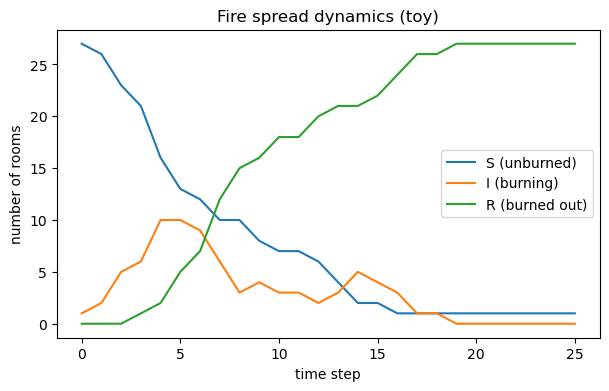

In [ ]:
t = np.arange(counts.shape[0])
plt.figure(figsize=(7, 4))
plt.plot(t, counts[:, 0], label="S (unburned)")
plt.plot(t, counts[:, 1], label="I (burning)")
plt.plot(t, counts[:, 2], label="R (burned out)")
plt.xlabel("time step")
plt.ylabel("number of rooms")
plt.title("Fire spread dynamics (toy)")
plt.legend()
plt.show()


## 5. Visualize the fire spreading on the building graph

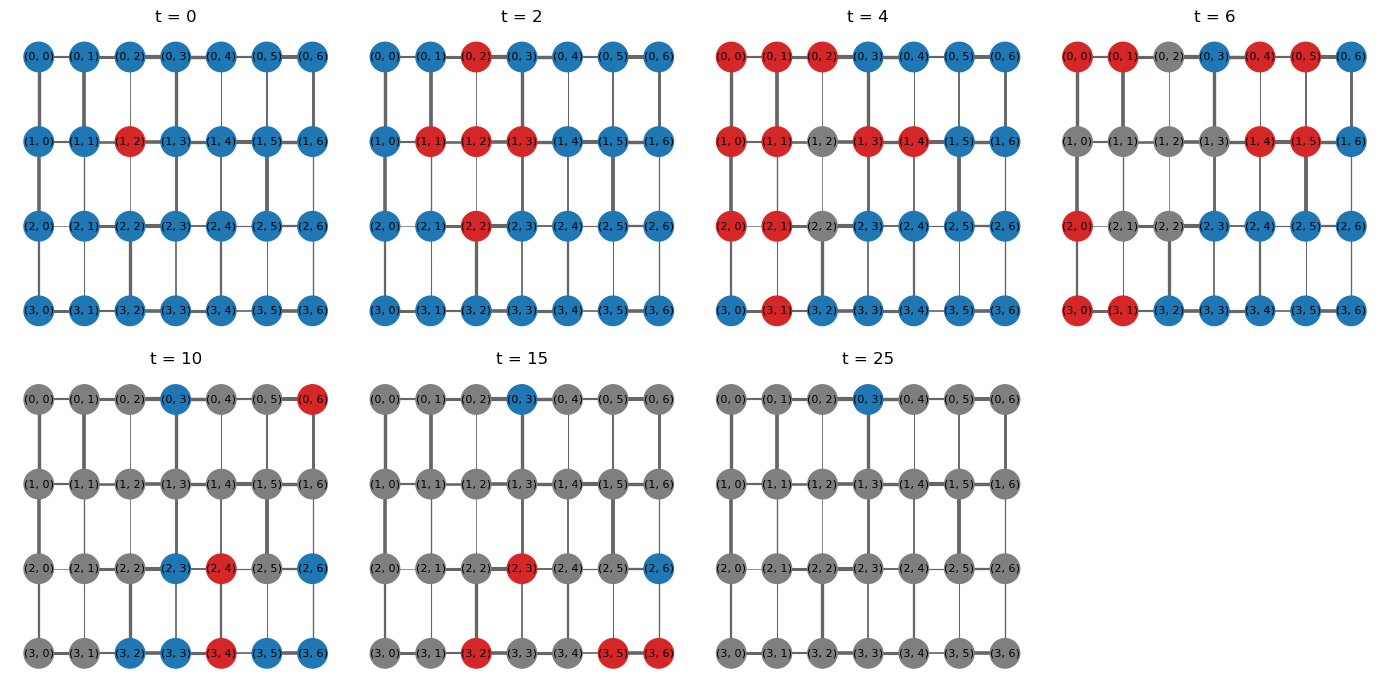

In [ ]:
def draw_state(G, pos, state, ax=None):
    """Draw one simulation snapshot with categorical node colors."""
    if ax is None:
        ax = plt.gca()

    color_map = {
        SUSCEPTIBLE: "tab:blue",
        BURNING: "tab:red",
        BURNED_OUT: "tab:gray",
    }
    node_colors = [color_map[state[n]] for n in G.nodes()]

    if G.number_of_edges() > 0:
        w = np.array([G[u][v]["w"] for u, v in G.edges()])
        widths = 0.5 + 2.5 * (w - w.min()) / (w.max() - w.min() + 1e-12)
    else:
        widths = 1.0

    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.6)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=450, node_color=node_colors)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
    ax.axis("off")


snapshots = [0, 2, 4, 6, 10, 15, 25]
snapshots = [s for s in snapshots if s < len(history)]

ncols = 4
nrows = int(np.ceil(len(snapshots) / ncols))
plt.figure(figsize=(14, 3.5 * nrows))

for i, s in enumerate(snapshots, 1):
    ax = plt.subplot(nrows, ncols, i)
    draw_state(G, pos, history[s], ax=ax)
    ax.set_title(f"t = {s}")

plt.tight_layout()
plt.show()

## 6. In-class experiments

1. Vary `beta` and compare outbreak size (`beta = 0.3, 0.6, 1.0, 2.0`).
2. Increase insulation by raising `weight_high` to `10.0`; evaluate whether spread is delayed or suppressed.
3. Test targeted mitigation by assigning very large `w` to selected edges (fire-door intervention).
4. Compare ignition location effects (corner vs. central room).
5. Optional threshold analysis: sweep `beta` and record final burned-out count.

## 7. Parameter-sweep template (`beta` vs. final damage)

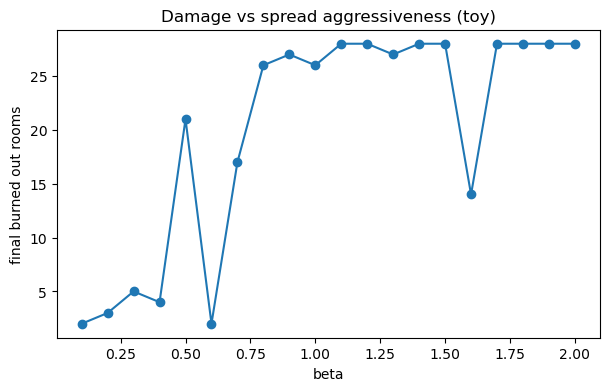

In [ ]:
# Template: sweep beta with repeated stochastic trials
betas = np.linspace(0.1, 2.0, 20)
runs = 20

mean_final_burned = []
std_final_burned = []

for i, beta in enumerate(betas):
    final_burned = []

    for r in range(runs):
        rng_run = np.random.default_rng(10_000 + i * 1_000 + r)
        params = FireParams(beta=float(beta), burn_time=3, max_steps=30)
        _, counts = simulate_fire(G, seed_nodes=[(1, 2)], params=params, rng=rng_run)
        final_burned.append(int(counts[-1, 2]))  # final number in R

    mean_final_burned.append(float(np.mean(final_burned)))
    std_final_burned.append(float(np.std(final_burned)))

plt.figure(figsize=(7, 4))
plt.errorbar(betas, mean_final_burned, yerr=std_final_burned, fmt="o-", capsize=3)
plt.xlabel("beta")
plt.ylabel("final burned-out rooms (mean +/- sd)")
plt.title(f"Damage vs spread intensity ({runs} runs per beta)")
plt.tight_layout()
plt.show()